In [16]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import torch
%matplotlib inline
from ultralytics import YOLO

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

PyTorch version: 2.5.1+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER


In [3]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATASET_YAML = PROJECT_ROOT / "src" / "yolo_pipeline" / "dataset.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"

print("Project root:", PROJECT_ROOT)
print("Dataset YAML:", DATASET_YAML)
print("Dataset YAML exists:", DATASET_YAML.exists())

Project root: e:\yolo_pothole
Dataset YAML: e:\yolo_pothole\src\yolo_pipeline\dataset.yaml
Dataset YAML exists: True


In [4]:
with open(DATASET_YAML, "r") as f:
    print(f.read())

path: e:\yolo_pothole\data\splits
train: images/train
val: images/val
test: images/test
names:
  0: pothole



In [5]:
model = YOLO("yolov8n.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_s

A pretrained YOLO nano model is used as the baseline. Starting from pretrained weights is useful because the model has already learned general visual features from a large dataset. The training process then fine-tunes these features for pothole detection.

The nano model is chosen for the first experiment because it is lightweight, fast to train, and suitable for checking whether the dataset and training pipeline work correctly. Larger models can be tested later after the baseline is working.

In [6]:
results = model.train(
    data=str(DATASET_YAML),
    epochs=50,
    imgsz=640,
    batch=16,
    project=str(RUNS_DIR / "train"),
    name="yolov8n_pothole_baseline",
    exist_ok=True,
    seed=42
)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


Ultralytics 8.4.45  Python-3.11.9 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 SUPER, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=e:\yolo_pothole\src\yolo_pipeline\dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_pothole_baseline, nbs=64, nms=False, opset=None, optimize=Fa

The baseline model is trained for 50 epochs with image size 640. This gives the model enough time to learn the pothole detection task while keeping the first experiment relatively lightweight.

The training outputs are saved under `runs/train/yolov8n_pothole_baseline`, including model checkpoints, loss curves, metric plots, and prediction examples.

In [7]:
TRAIN_RUN_DIR = RUNS_DIR / "train" / "yolov8n_pothole_baseline"

print("Training output folder:", TRAIN_RUN_DIR)
print("Exists:", TRAIN_RUN_DIR.exists())

for item in TRAIN_RUN_DIR.iterdir():
    print(item.name)

Training output folder: e:\yolo_pothole\runs\train\yolov8n_pothole_baseline
Exists: True
args.yaml
BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch1360.jpg
train_batch1361.jpg
train_batch1362.jpg
train_batch2.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


In [8]:
results_csv = TRAIN_RUN_DIR / "results.csv"

df_results = pd.read_csv(results_csv)
df_results.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,6.32171,1.67287,2.69226,1.53459,0.00808,0.85561,0.15217,0.07126,1.77673,3.33194,1.57838,0.000647,0.000647,0.000647
1,2,9.76037,1.56694,2.07600,1.47502,0.62834,0.28342,0.35215,0.19647,1.54356,2.45158,1.56154,0.001288,0.001288,0.001288
2,3,12.99760,1.60341,1.97827,1.47682,0.22779,0.21925,0.14559,0.06467,1.83597,6.04231,1.90780,0.001902,0.001902,0.001902
3,4,16.38610,1.56411,1.77646,1.44757,0.53949,0.35829,0.35761,0.17890,1.91668,2.54321,1.83601,0.001881,0.001881,0.001881
4,5,19.76830,1.59305,1.71552,1.47279,0.63301,0.47965,0.52821,0.24302,1.59948,2.31589,1.95776,0.001842,0.001842,0.001842


In [9]:
df_results.columns = df_results.columns.str.strip()
df_results.tail()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
45,46,281.681,0.90598,0.63388,1.02478,0.81151,0.78278,0.83807,0.53626,1.23025,0.97308,1.23829,0.000218,0.000218,0.000218
46,47,288.016,0.90376,0.63301,1.03071,0.82892,0.70588,0.82391,0.54278,1.15874,0.89241,1.20066,0.000178,0.000178,0.000178
47,48,294.385,0.88624,0.63726,1.02918,0.84876,0.72193,0.83505,0.54587,1.22963,0.96932,1.26398,0.000139,0.000139,0.000139
48,49,300.450,0.88088,0.60536,1.01926,0.80822,0.80749,0.85241,0.54799,1.20132,0.96178,1.24998,0.000099,0.000099,0.000099
49,50,306.612,0.86992,0.59352,1.00753,0.82972,0.75566,0.84204,0.54368,1.20093,0.97279,1.21746,0.000060,0.000060,0.000060


['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
Available loss columns: ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss']


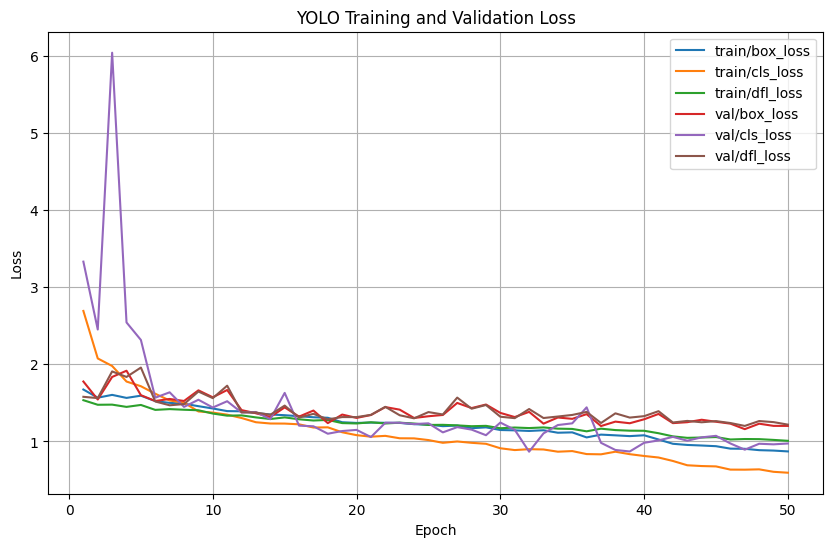

In [17]:
# Clean column names first
df_results.columns = df_results.columns.str.strip()

print(df_results.columns.tolist())

loss_cols = [
    "train/box_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "val/box_loss",
    "val/cls_loss",
    "val/dfl_loss"
]

available_loss_cols = [col for col in loss_cols if col in df_results.columns]

print("Available loss columns:", available_loss_cols)

plt.figure(figsize=(10, 6))

for col in available_loss_cols:
    plt.plot(df_results["epoch"], df_results[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLO Training and Validation Loss")

if available_loss_cols:
    plt.legend()

plt.grid(True)
plt.show()

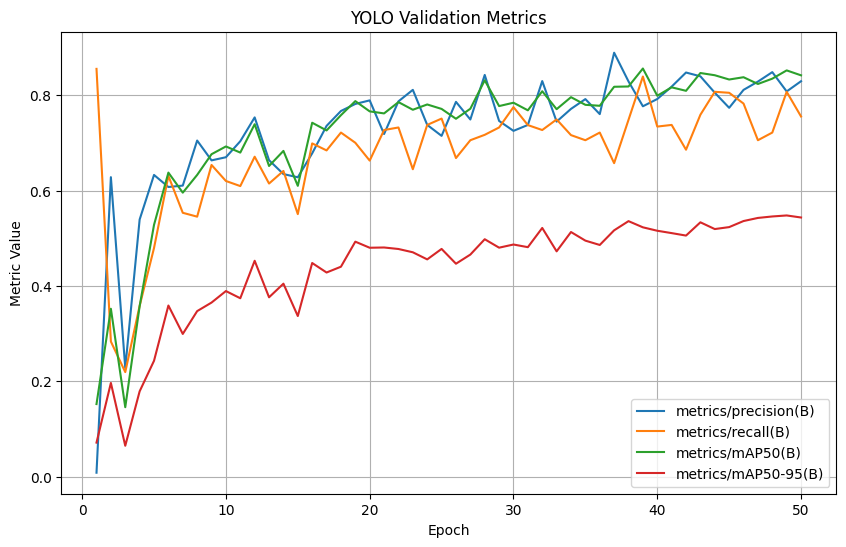

In [18]:
metric_cols = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)"
]

available_metric_cols = [col for col in metric_cols if col in df_results.columns]

plt.figure(figsize=(10, 6))

for col in available_metric_cols:
    plt.plot(df_results["epoch"], df_results[col], label=col)

plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("YOLO Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()

## Result

The YOLOv8n baseline was trained for 50 epochs using image size 640 and batch size 16. Training completed successfully on the GPU.

The final validation summary reports performance on 66 validation images containing 187 pothole instances. The best model achieved approximately:

- Precision: 0.814
- Recall: 0.802
- mAP50: 0.853
- mAP50-95: 0.549

This is a strong first baseline. The high mAP50 suggests that the model is generally able to detect potholes well at a standard IoU threshold. The lower mAP50-95 is expected because that metric is stricter and requires more accurate localization across multiple IoU thresholds.

The loss curves show that the model is learning throughout training.

The training losses decrease clearly over the 50 epochs. The classification loss drops strongly from around 2.69 at the beginning to around 0.59 by the final epoch, showing that the model becomes much better at identifying the pothole class. The box loss also decreases from around 1.67 to around 0.87, meaning the predicted bounding boxes become more accurate over time.

The validation losses are more unstable in the early epochs, especially the validation classification loss, which spikes early in training. This is normal for an early baseline because the model is still adapting from general pretrained features to the pothole dataset. After the early epochs, the validation losses become more stable.

Overall, the training curves suggest that the model is learning effectively. There is some gap between training and validation losses, but the validation metrics continue to improve, so the baseline does not show severe overfitting at this stage.

The validation metrics improve significantly during training.

At the start, the model performs inconsistently, which is expected because it has not yet adapted to the pothole dataset. After the first few epochs, precision, recall, and mAP increase quickly.

By the later epochs, precision and recall are both generally around the 0.75–0.85 range. This means the model is reasonably balanced: it can find many real potholes while also keeping false detections under control.

The mAP50 curve reaches around 0.85, which indicates strong detection performance at an IoU threshold of 0.50. The mAP50-95 curve reaches around 0.55, which is lower but expected because it is a stricter metric that requires more accurate bounding box localization across multiple IoU thresholds.

This result suggests that the baseline YOLO model can detect potholes well, but there is still room to improve localization precision.